In [10]:
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df.job_posted_date)
df['job_skills'] = df['job_skills'].apply(lambda x:ast.literal_eval(x) if pd.notna(x) else x)

###  Filter for US Data Analyst roles

In [11]:
df_DA_US = df[(df['job_country']=='United States') & (df['job_title_short'] == 'Data Analyst')]

Text(0.5, 1.0, 'Counts of jobs in job locations in United States')

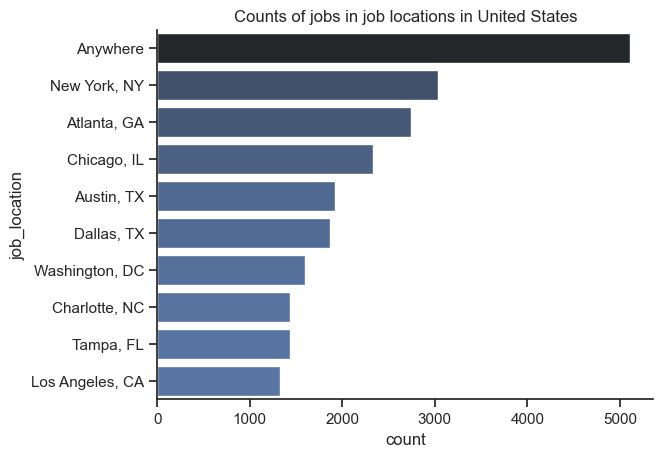

In [14]:
df_plot = df_DA_US['job_location'].value_counts().head(10).to_frame()

sns.set_theme(style='ticks')
sns.barplot(data=df_plot, x='count' , y='job_location', hue='count' , palette='dark:b_r', legend=False)
sns.despine()
plt.title('Counts of jobs in job locations in United States')


In [ ]:
#df_DA_US.head(2)

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
36,Data Analyst,Data Analyst,"Des Moines, IA",via Trabajo.org,Full-time,False,"Illinois, United States",2023-11-06 13:01:22,False,True,United States,NaN,NaN,NaN,Assuredpartners,NaN,NaN
68,Data Analyst,Sr. Research Data Analyst,"Baltimore, MD",via ZipRecruiter,Full-time,False,"New York, United States",2023-03-24 13:01:00,False,False,United States,NaN,NaN,NaN,Johns Hopkins Medicine,"[r, zoom]","{'programming': ['r'], 'sync': ['zoom']}"


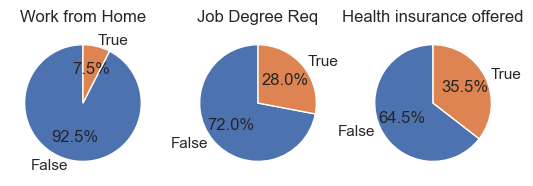

In [18]:
fig,ax = plt.subplots(1,3)

dict_column ={
            'job_work_from_home':'Work from Home',
            'job_no_degree_mention':'Job Degree Req',
            'job_health_insurance':'Health insurance offered'
}

for i,(column,title) in enumerate(dict_column.items()):
    ax[i].pie(df_DA_US[column].value_counts(),startangle=90,autopct='%1.1f%%',labels=[False,True])
    ax[i].set_title(title)

Text(0.5, 1.0, 'Counts of jobs in companies for Data Analyst in United States')

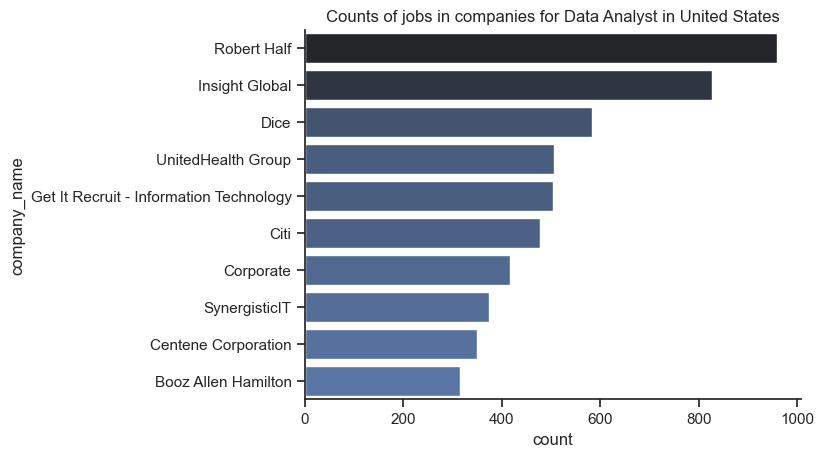

In [ ]:
df_plot = df_DA_US['company_name'].value_counts().head(10).to_frame()  ##to_frame to convert into dataframe
########Ctrl+ shift +L
sns.set_theme(style='ticks')
sns.barplot(data=df_plot, x='count' , y='company_name', hue='count' , palette='dark:b_r', legend=False)
sns.despine()
plt.title('Counts of jobs in companies for Data Analyst in United States')